First 5 records:
          date     price  bedrooms  grade  has_basement  living_in_m2  \
0  2014-05-15  312000.0         2      2          True     138.42547   
1  2014-11-14  310000.0         2      2         False     105.90942   
2  2014-12-24  320000.0         2      2         False     117.98681   
3  2015-02-22  264500.0         2      3         False     151.43189   
4  2015-01-06  700000.0         3      2          True     341.88304   

   renovated  nice_view  perfect_condition  real_bathrooms  has_lavatory  \
0      False      False              False               2          True   
1      False      False              False               1          True   
2      False       True              False               1         False   
3      False      False              False               2          True   
4      False      False              False               3         False   

   single_floor  month  quartile_zone  
0         False      5              1  
1         Fa

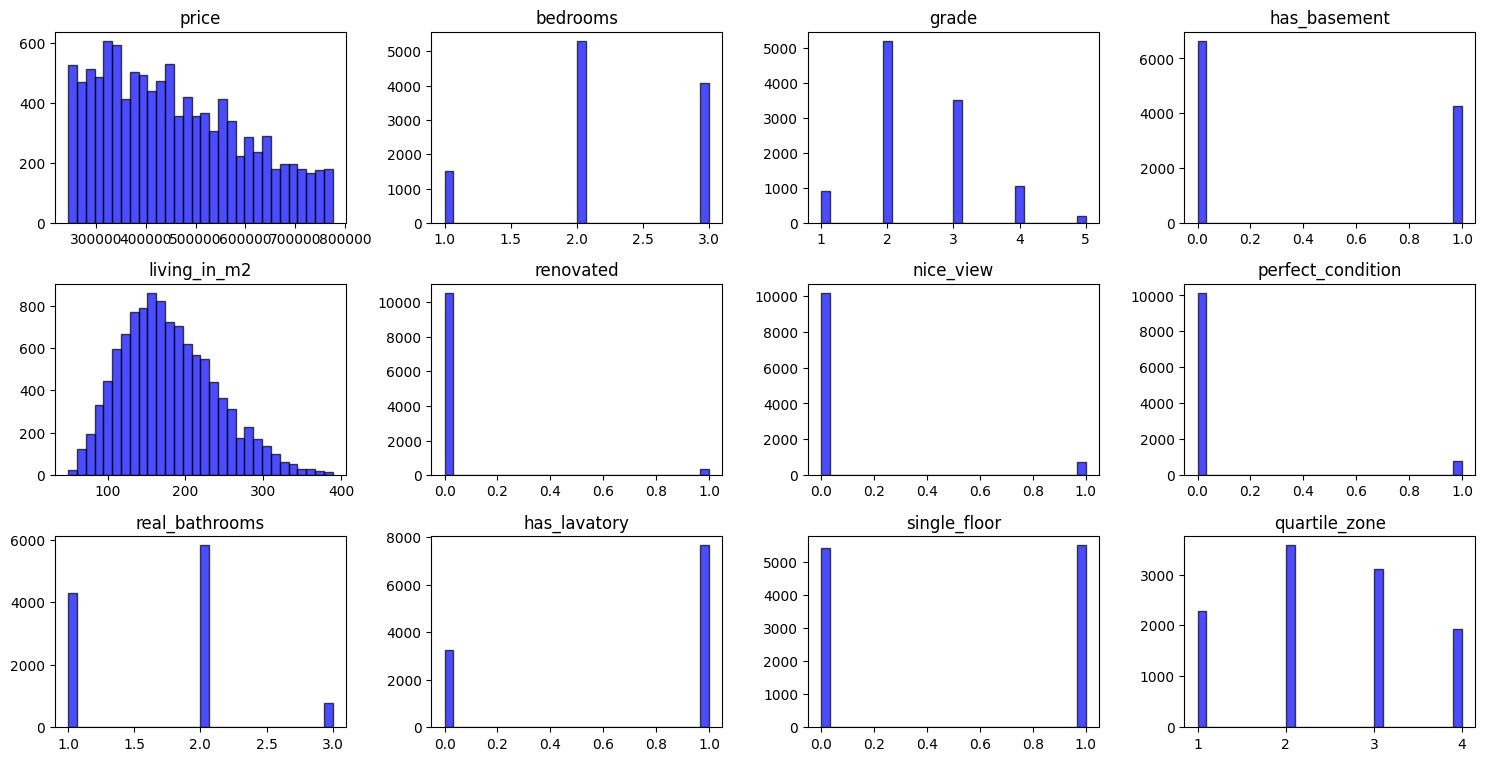


Final cleaned DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 10901 entries, 0 to 13602
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              10901 non-null  float64
 1   bedrooms           10901 non-null  int64  
 2   grade              10901 non-null  int64  
 3   has_basement       10901 non-null  int64  
 4   living_in_m2       10901 non-null  float64
 5   renovated          10901 non-null  int64  
 6   nice_view          10901 non-null  int64  
 7   perfect_condition  10901 non-null  int64  
 8   real_bathrooms     10901 non-null  int64  
 9   has_lavatory       10901 non-null  int64  
 10  single_floor       10901 non-null  int64  
 11  quartile_zone      10901 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 1.1 MB
None

First 5 records of cleaned DataFrame:
       price  bedrooms  grade  has_basement  living_in_m2  renovated  \
0  312000.0         2     

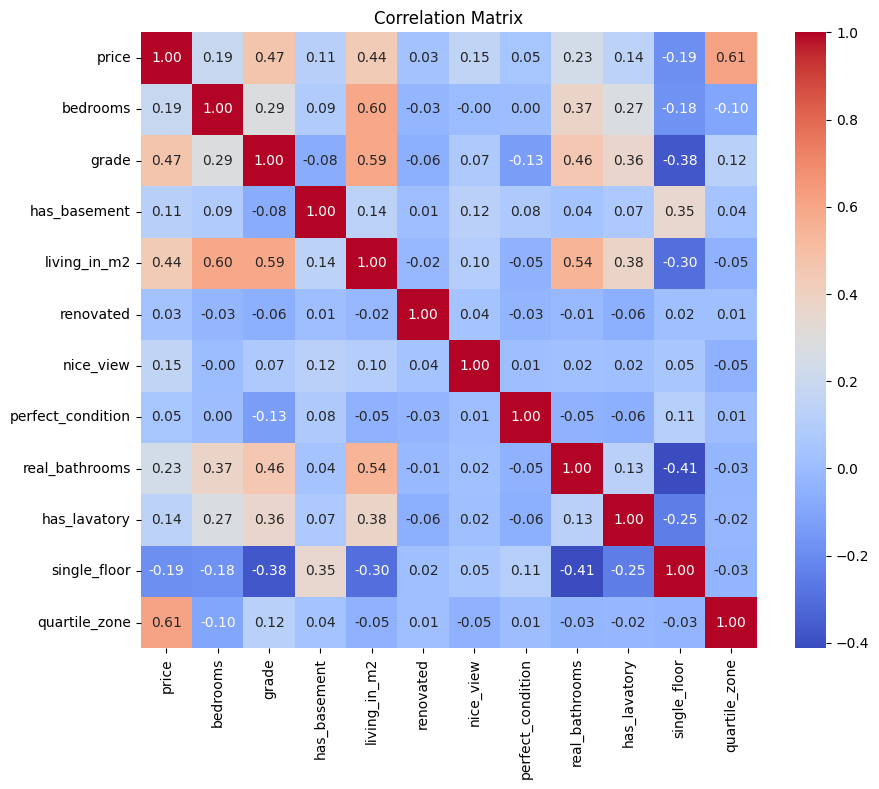

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Set the path to the file you'd like to load
file_path = "df_train.csv"
file_path_test = "df_test.csv"

# Load the CSV with the correct encoding
df_train = pd.read_csv(file_path, encoding='utf-8', delimiter=',', decimal='.')
df_test = pd.read_csv(file_path_test, encoding='utf-8', delimiter=',', decimal='.')

print("First 5 records:\n", df_train.head())

print("\nEDA Summary:")
print(df_train.describe())

print("\nMissing values per column:\n", df_train.isnull().sum())

print("\nData types:\n", df_train.dtypes)

print("\nDataFrame shape after deletion:", df_train.shape)

print("\nColumn names:", df_train.columns.tolist())

print("\nDeleting rows with any missing values...")
df_train = df_train.dropna()
df_test = df_test.dropna()

print("\nDataFrame shape after deleting rows with missing values:", df_train.shape)

print("\nDeleting duplicate rows...")
df_train = df_train.drop_duplicates()
df_test = df_test.drop_duplicates()

print("\nDataFrame shape after deleting duplicate rows:", df_train.shape)

print("\nDeleting date columns...")
date_columns = [col for col in df_train.columns if 'date' in col.lower() or 'month' in col.lower()]
df_train = df_train.drop(columns=date_columns)
df_test = df_test.drop(columns=date_columns)

print("\nDataFrame shape after datetime deletion:", df_train.shape)

print("\nDeleting outliers. Values less than 10% or more than 90% quantiles for 'price' column...")
if 'price' in df_train.columns:
    lower_bound = df_train['price'].quantile(0.10)
    upper_bound = df_train['price'].quantile(0.90)
    df_train = df_train[(df_train['price'] >= lower_bound) & (df_train['price'] <= upper_bound)]
    print("\nDataFrame shape after deleting outliers in 'price':", df_train.shape)
    
if 'price' in df_test.columns:
    lower_bound_test = df_test['price'].quantile(0.10)
    upper_bound_test = df_test['price'].quantile(0.90)
    df_test = df_test[(df_test['price'] >= lower_bound_test) & (df_test['price'] <= upper_bound_test)]
    print("\nDataFrame shape after deleting outliers in 'price' for test set:", df_test.shape)
    
print("\nConverting boolean columns to integers...")
bool_cols = df_train.select_dtypes(include=['bool']).columns
df_train[bool_cols] = df_train[bool_cols].astype(int)
df_test[bool_cols] = df_test[bool_cols].astype(int)
    
print("\nPlotting hist plots for numeric columns...")
df_train.hist(bins=30, figsize=(15, 10), layout=(4, 4), color='blue', edgecolor='black', alpha=0.7, grid=False)
plt.tight_layout()
plt.show()

print("\nFinal cleaned DataFrame info:")
print(df_train.info())

print("\nFirst 5 records of cleaned DataFrame:\n", df_train.head())

print("\nData cleaning completed.")

print("\nMatrix of correlations:\n")
correlation_matrix = df_train.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.show()

# Creando la red neuronal

Entrenando Modelo 1 (1 característica)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8234  
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8161  
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 957us/step - loss: 0.8146
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8171
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8135  
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - loss: 0.8158
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - loss: 0.8162
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8173  
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - loss: 0.8142
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8136
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8127
Epoch 12/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step - loss: 0.8116
Epoch 13/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8140  
Epoch 14/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8137
Epoch 15/200
341/341 ━━━━━━━━━━━━━━

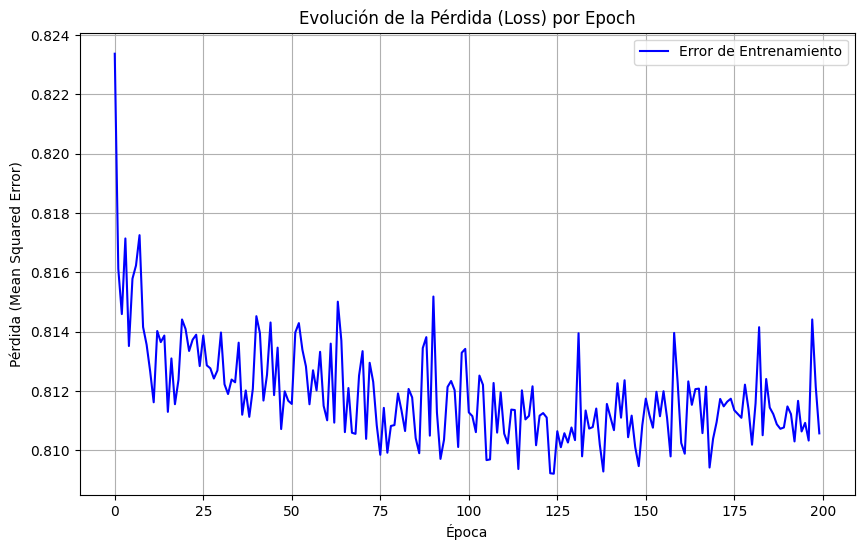

In [27]:
# --- FASE 1: UNA CARACTERÍSTICA ---
# Seleccionamos 'living_in_m2' por su alta correlación
feature_single = ['living_in_m2']
X_train_1 = df_train[feature_single]
y_train_1 = df_train['price']
X_test_1 = df_test[feature_single]
y_test_1 = df_test['price']

# Escalado
scaler_x1 = StandardScaler()
scaler_y1 = StandardScaler()

X_train_1_s = scaler_x1.fit_transform(X_train_1)
y_train_1_s = scaler_y1.fit_transform(y_train_1.values.reshape(-1, 1))
X_test_1_s = scaler_x1.transform(X_test_1)
y_test_1_s = scaler_y1.transform(y_test_1.values.reshape(-1, 1))

# Modelo Simple
model_1 = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[len(feature_single)], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_1.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_squared_error')
print('Entrenando Modelo 1 (1 característica)...')
history_1 = model_1.fit(X_train_1_s, y_train_1_s, epochs=200)

# Evaluación
loss_1 = model_1.evaluate(X_test_1_s, y_test_1_s, verbose=0)
print(f'Pérdida Modelo 1 en Test: {loss_1}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_1.history['loss'], color='blue', label='Error de Entrenamiento')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

Entrenando Modelo 2 (Múltiples características)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.4011
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3787
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3736
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3702
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3717
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3719
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3728
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3684
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3697
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3690
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3669
Epoch 12/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3696
Epoch 13/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3688
Epoch 14/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3683
Epoch 15/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step -

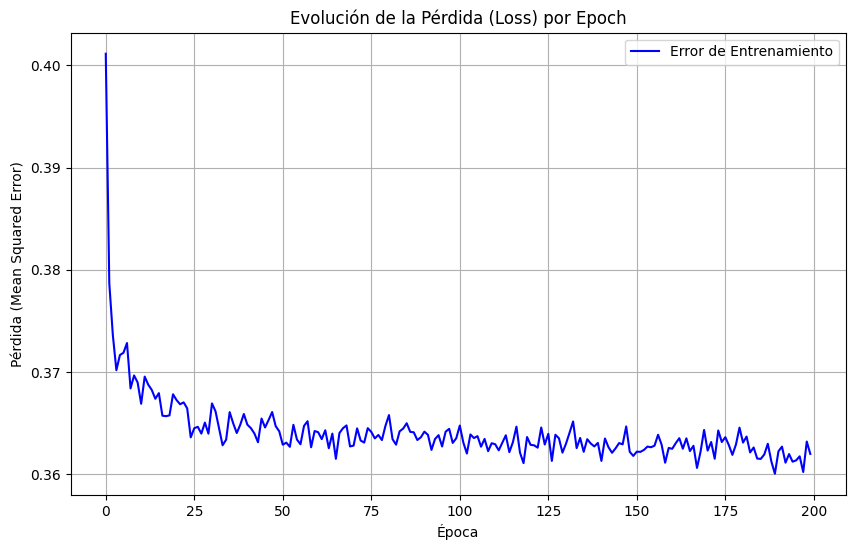

In [12]:
# --- FASE 2: MÚLTIPLES CARACTERÍSTICAS ---
features_multi = ['living_in_m2', 'grade', 'quartile_zone']
X_train_M = df_train[features_multi]
y_train_M = df_train['price']
X_test_M = df_test[features_multi]
y_test_M = df_test['price']

# Escalado
scaler_xM = StandardScaler()
scaler_yM = StandardScaler()

X_train_M_s = scaler_xM.fit_transform(X_train_M)
y_train_M_s = scaler_yM.fit_transform(y_train_M.values.reshape(-1, 1))
X_test_M_s = scaler_xM.transform(X_test_M)
y_test_M_s = scaler_yM.transform(y_test_M.values.reshape(-1, 1))

# Modelo Multivariable
model_M = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[len(features_multi)], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_M.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_squared_error')
print('Entrenando Modelo 2 (Múltiples características)...')
history_M = model_M.fit(X_train_M_s, y_train_M_s, epochs=200)

# Evaluación
loss_M = model_M.evaluate(X_test_M_s, y_test_M_s, verbose=0)
print(f'Pérdida Modelo 2 en Test: {loss_M}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_M.history['loss'], color='blue', label='Error de Entrenamiento')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

Entrenando Modelo 1 (1 característica)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


341/341 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7556
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7542
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7525
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7507
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7509
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7532
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7497
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7505
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7516
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7496
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7497
Epoch 12/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7504
Epoch 13/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7505
Epoch 14/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7497
Epoch 15/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step -

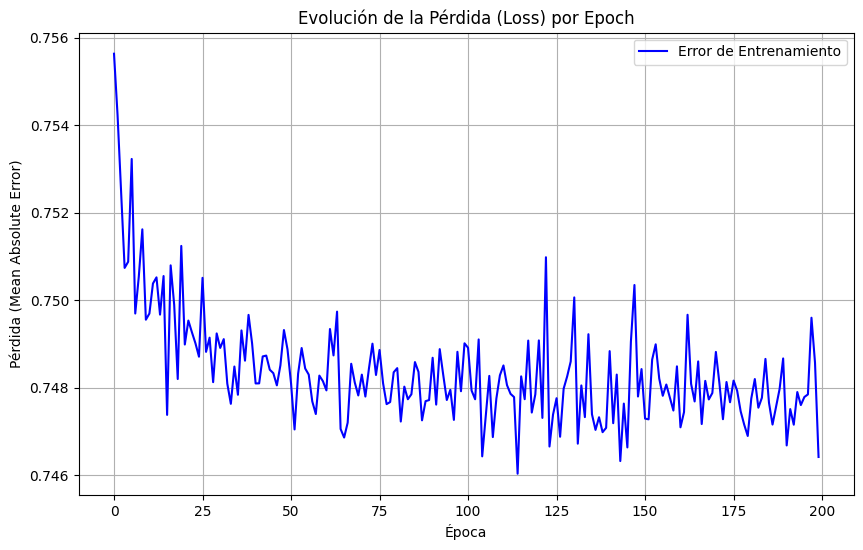

In [13]:
# --- FASE 3: UNA CARACTERÍSTICA CON ABSOLUTE ERROR ---
# Seleccionamos 'living_in_m2' por su alta correlación
feature_single = ['living_in_m2']
X_train_1_a = df_train[feature_single]
y_train_1_a = df_train['price']
X_test_1_a = df_test[feature_single]
y_test_1_a = df_test['price']

# Escalado
scaler_x1 = StandardScaler()
scaler_y1 = StandardScaler()

X_train_1_a_s = scaler_x1.fit_transform(X_train_1_a)
y_train_1_a_s = scaler_y1.fit_transform(y_train_1_a.values.reshape(-1, 1))
X_test_1_a_s = scaler_x1.transform(X_test_1_a)
y_test_1_a_s = scaler_y1.transform(y_test_1_a.values.reshape(-1, 1))

# Modelo Simple
model_1_a = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[len(feature_single)], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_1_a.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_absolute_error')
print('Entrenando Modelo 1 (1 característica)...')
history_1_a = model_1_a.fit(X_train_1_a_s, y_train_1_a_s, epochs=200)

# Evaluación
loss_1_a = model_1_a.evaluate(X_test_1_a_s, y_test_1_a_s, verbose=0)
print(f'Pérdida Modelo 1 en Test: {loss_1_a}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_1_a.history['loss'], color='blue', label='Error de Entrenamiento')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Absolute Error)')
plt.legend()
plt.grid(True)
plt.show()

Entrenando Modelo 2 (Múltiples características)...
Epoch 1/200


c:\Users\ampr2\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4855
Epoch 2/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4736
Epoch 3/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4747
Epoch 4/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - loss: 0.4676
Epoch 5/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4693  
Epoch 6/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4695
Epoch 7/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4671
Epoch 8/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4671
Epoch 9/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4663
Epoch 10/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4676
Epoch 11/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4661
Epoch 12/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4658
Epoch 13/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4643
Epoch 14/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4641
Epoch 15/200
341/341 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/st

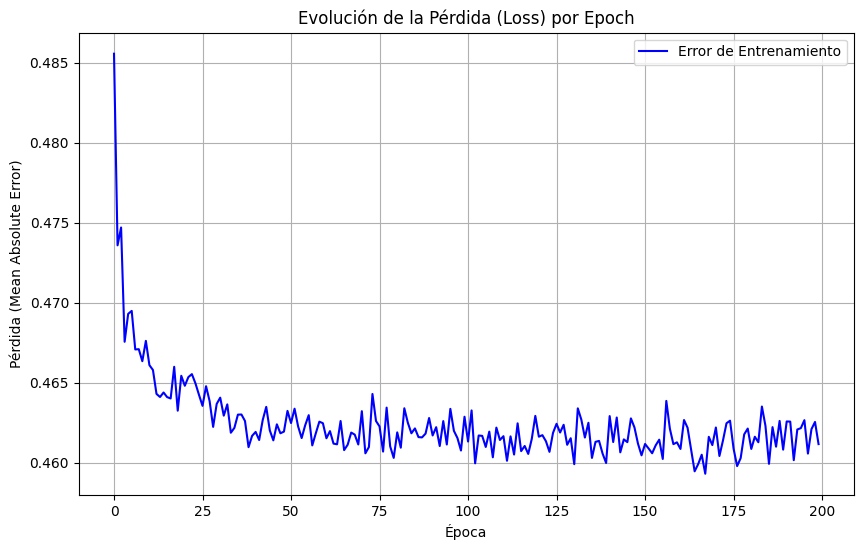

In [15]:
# --- FASE 4: MÚLTIPLES CARACTERÍSTICAS CON ABSOLUTE ERROR ---
features_multi = ['living_in_m2', 'grade', 'quartile_zone']
X_train_M_a = df_train[features_multi]
y_train_M_a = df_train['price']
X_test_M_a = df_test[features_multi]
y_test_M_a = df_test['price']

# Escalado
scaler_xM = StandardScaler()
scaler_yM = StandardScaler()

X_train_M_a_s = scaler_xM.fit_transform(X_train_M_a)
y_train_M_a_s = scaler_yM.fit_transform(y_train_M_a.values.reshape(-1, 1))
X_test_M_a_s = scaler_xM.transform(X_test_M_a)
y_test_M_a_s = scaler_yM.transform(y_test_M_a.values.reshape(-1, 1))

# Modelo Multivariable
model_M_a = tf.keras.Sequential([
    # Etapa 1: Gran capacidad de captura
    tf.keras.layers.Dense(units=64, input_shape=[len(features_multi)], activation='relu'),
    # Etapa 2: Reducción y combinación
    tf.keras.layers.Dense(units=32, activation='relu'),
    # Etapa 3: Abstracción
    tf.keras.layers.Dense(units=16, activation='relu'),
    # Etapa 4: Refinamiento pre-salida
    tf.keras.layers.Dense(units=8, activation='relu'),
    # Salida
    tf.keras.layers.Dense(units=1)
])

model_M_a.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mean_absolute_error')
print('Entrenando Modelo 2 (Múltiples características)...')
history_M_a = model_M_a.fit(X_train_M_a_s, y_train_M_a_s, epochs=200)

# Evaluación
loss_M_a = model_M_a.evaluate(X_test_M_a_s, y_test_M_a_s, verbose=0)
print(f'Pérdida Modelo 2 en Test: {loss_M_a}')

# Plot del proceso de los epochs
plt.figure(figsize=(10, 6))
plt.plot(history_M_a.history['loss'], color='blue', label='Error de Entrenamiento')
plt.title('Evolución de la Pérdida (Loss) por Epoch')
plt.xlabel('Época')
plt.ylabel('Pérdida (Mean Absolute Error)')
plt.legend()
plt.grid(True)
plt.show()

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 791us/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step


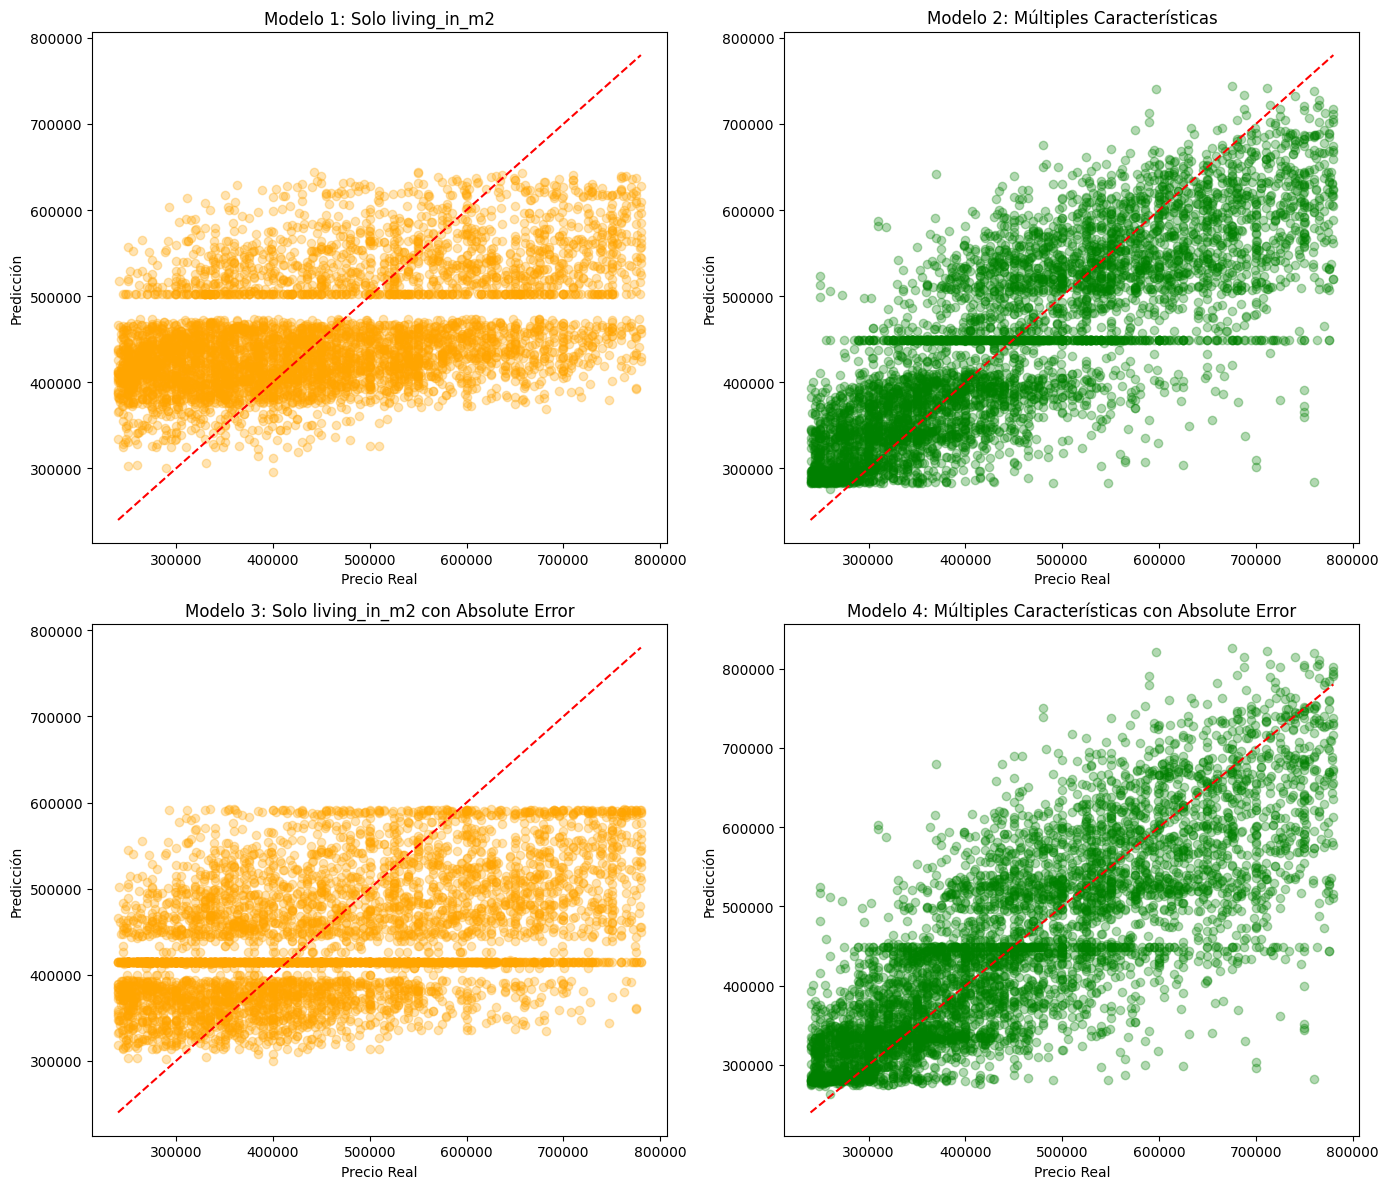


Comparativa de predicciones:
       Real   Pred_Simple    Pred_Multi  Pred_Simple_Absoluto  \
0  305000.0  354753.34375  317953.71875          327646.53125   
1  498000.0  502950.15625  404996.18750          473492.50000   
2  590000.0  555512.81250  559631.87500          543804.31250   
3  775000.0  431894.93750  531095.37500          414941.56250   
4  350000.0  380334.09375  390149.68750          345001.43750   
5  399000.0  464120.46875  319283.68750          460936.81250   
6  325000.0  381766.34375  448915.09375          346929.75000   
7  250000.0  445501.28125  300135.28125          414941.56250   
8  445000.0  633805.12500  506189.68750          586591.18750   
9  459500.0  398237.18750  448915.09375          369105.43750   

   Pred_Multi_Absoluto  
0         312339.81250  
1         407506.06250  
2         594347.00000  
3         531853.06250  
4         377324.62500  
5         318878.21875  
6         428483.46875  
7         293692.40625  
8         508491.34375  
9   

In [29]:
# Predicciones
pred_1 = scaler_y1.inverse_transform(model_1.predict(X_test_1_s))
pred_M = scaler_yM.inverse_transform(model_M.predict(X_test_M_s))
pred_1_a = scaler_y1.inverse_transform(model_1_a.predict(X_test_1_a_s))
pred_M_a = scaler_yM.inverse_transform(model_M_a.predict(X_test_M_a_s))

# Visualización
plt.figure(figsize=(14, 12))

plt.subplot(2, 2, 1)
plt.scatter(y_test_1, pred_1, alpha=0.3, color='orange')
plt.plot([y_test_1.min(), y_test_1.max()], [y_test_1.min(), y_test_1.max()], 'r--')
plt.title('Modelo 1: Solo living_in_m2')
plt.xlabel('Precio Real')
plt.ylabel('Predicción')

plt.subplot(2, 2, 2)
plt.scatter(y_test_M, pred_M, alpha=0.3, color='green')
plt.plot([y_test_M.min(), y_test_M.max()], [y_test_M.min(), y_test_M.max()], 'r--')
plt.title('Modelo 2: Múltiples Características')
plt.xlabel('Precio Real')
plt.ylabel('Predicción')

plt.subplot(2, 2, 3)
plt.scatter(y_test_1_a, pred_1_a, alpha=0.3, color='orange')
plt.plot([y_test_1_a.min(), y_test_1_a.max()], [y_test_1_a.min(), y_test_1_a.max()], 'r--')
plt.title('Modelo 3: Solo living_in_m2 con Absolute Error')
plt.xlabel('Precio Real')
plt.ylabel('Predicción')

plt.subplot(2, 2, 4)
plt.scatter(y_test_M_a, pred_M_a, alpha=0.3, color='green')
plt.plot([y_test_M_a.min(), y_test_M_a.max()], [y_test_M_a.min(), y_test_M_a.max()], 'r--')
plt.title('Modelo 4: Múltiples Características con Absolute Error')
plt.xlabel('Precio Real')
plt.ylabel('Predicción')

plt.tight_layout()
plt.show()

# Tabla comparativa de los primeros 10 registros
comparativa = pd.DataFrame({
    'Real': y_test_1.values[:10],
    'Pred_Simple': pred_1.flatten()[:10],
    'Pred_Multi': pred_M.flatten()[:10],
    'Pred_Simple_Absoluto': pred_1_a.flatten()[:10],
    'Pred_Multi_Absoluto': pred_M_a.flatten()[:10]
})

diferencias = pd.DataFrame({
    'Real': y_test_1.values[:10],
    'Diferencia_Simple_Cuadratico_Real': (pred_1.flatten()[:10] - y_test_1.values[:10]),
    'Diferencia_Multi_Cuadratico_Real': (pred_M.flatten()[:10] - y_test_1.values[:10]),
    'Diferencia_Simple_Absoluto_Real': (pred_1_a.flatten()[:10] - y_test_1.values[:10]),
    'Diferencia_Multi_Absoluto_Real': (pred_M_a.flatten()[:10] - y_test_1.values[:10]),
    'Ganador_Cuadratico': np.where(
        abs(pred_1.flatten()[:10] - y_test_1.values[:10]) <
        abs(pred_M.flatten()[:10] - y_test_1.values[:10]),
        'Simple',
        'Multi'
    ),
    'Ganador_Absoluto': np.where(
        abs(pred_1_a.flatten()[:10] - y_test_1.values[:10]) <
        abs(pred_M_a.flatten()[:10] - y_test_1.values[:10]),
        'Simple',
        'Multi'
    )
})

cols_error = [
    'Diferencia_Simple_Cuadratico_Real', 
    'Diferencia_Multi_Cuadratico_Real', 
    'Diferencia_Simple_Absoluto_Real', 
    'Diferencia_Multi_Absoluto_Real'
]

diferencias['Ganador_Global'] = diferencias[cols_error].abs().idxmin(axis=1).replace({
    'Diferencia_Simple_Cuadratico_Real': 'Simple Cuadrático',
    'Diferencia_Multi_Cuadratico_Real': 'Multi Cuadrático',
    'Diferencia_Simple_Absoluto_Real': 'Simple Absoluto',
    'Diferencia_Multi_Absoluto_Real': 'Multi Absoluto'
})

diferencias = diferencias.drop(columns=['Ganador_Cuadratico', 'Ganador_Absoluto'])

print('\nComparativa de predicciones:')
print(comparativa)
print('\nDiferencias entre predicciones y valores reales:')
print(diferencias)


Resumen de Ganadores Globales y Error Medio:
                   Número de Victorias  Porcentaje de Victoria  \
Multi Absoluto                    2310               42.881010   
Multi Cuadrático                  1477               27.417858   
Simple Cuadrático                  862               16.001485   
Simple Absoluto                    738               13.699647   

                   Media Error Absoluto (MAE)  
Multi Absoluto                   65971.872111  
Multi Cuadrático                 66227.932592  
Simple Cuadrático               106855.783391  
Simple Absoluto                 106689.077490  

El modelo con más victorias es: Multi Absoluto


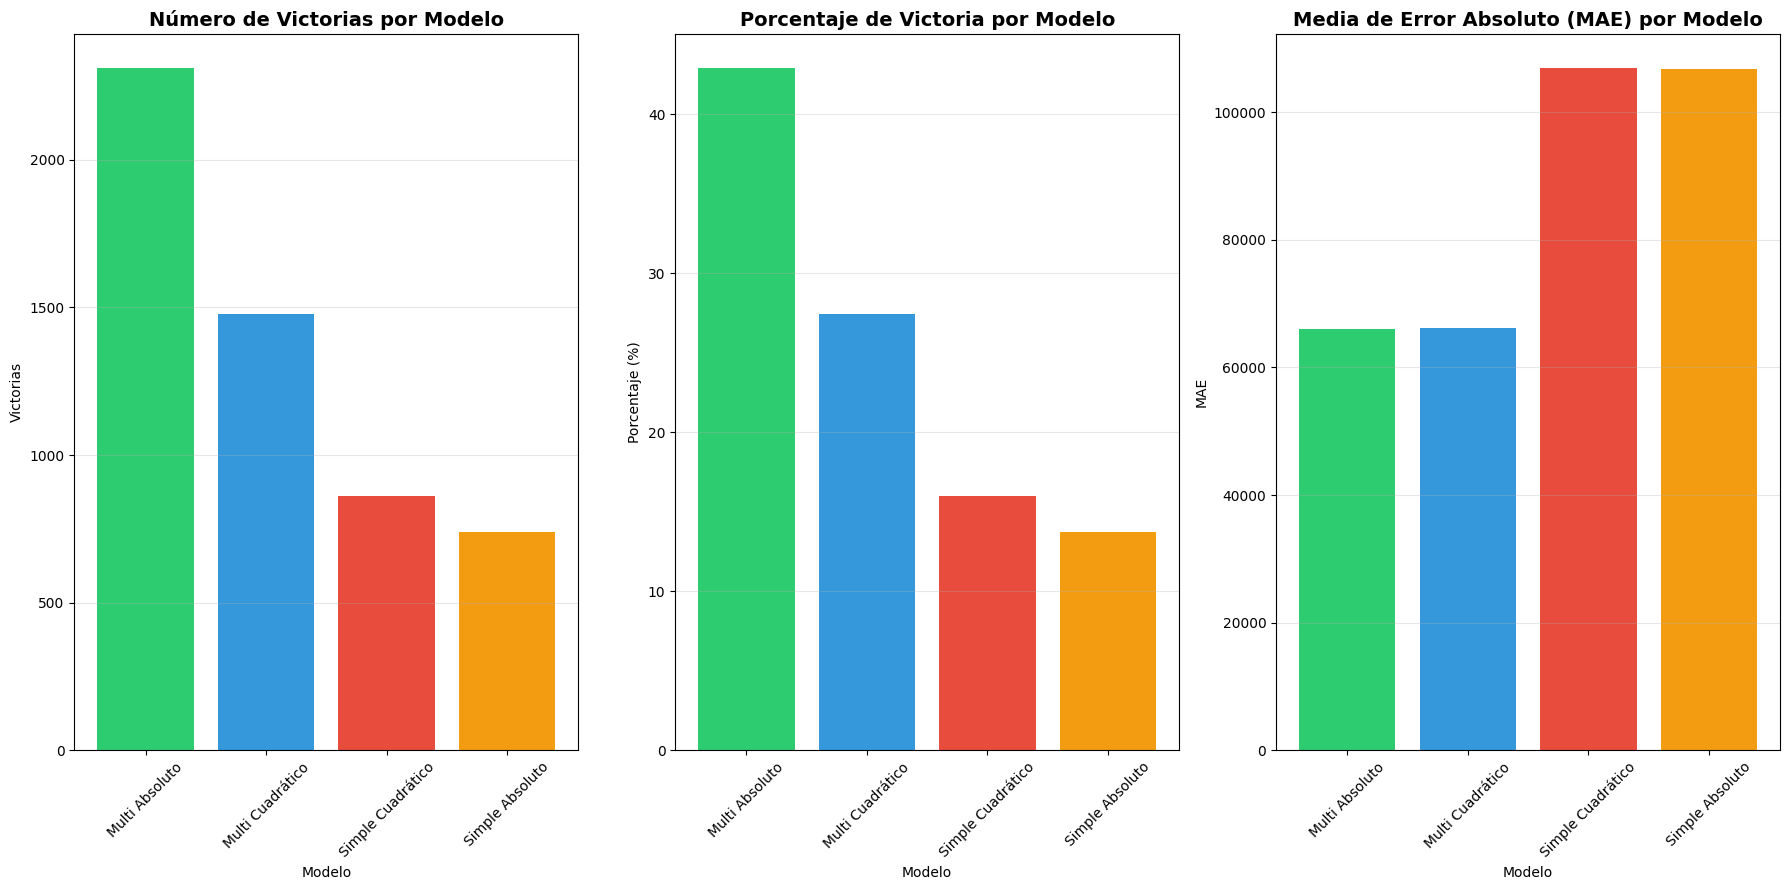

In [37]:
errores_totales = pd.DataFrame({
    'Simple Cuadrático': np.abs(pred_1.flatten() - y_test_1.values),
    'Multi Cuadrático': np.abs(pred_M.flatten() - y_test_1.values),
    'Simple Absoluto': np.abs(pred_1_a.flatten() - y_test_1.values),
    'Multi Absoluto': np.abs(pred_M_a.flatten() - y_test_1.values)
})

ganador_por_registro = errores_totales.idxmin(axis=1)

conteo_victorias = ganador_por_registro.value_counts()
porcentaje_victorias = ganador_por_registro.value_counts(normalize=True) * 100
media_errores = errores_totales.mean()

resumen_rendimiento = pd.DataFrame({
    'Número de Victorias': conteo_victorias,
    'Porcentaje de Victoria': porcentaje_victorias,
    'Media Error Absoluto (MAE)': media_errores
})

resumen_rendimiento = resumen_rendimiento.sort_values(by='Número de Victorias', ascending=False)

print('\nResumen de Ganadores Globales y Error Medio:')
print(resumen_rendimiento)

modelo_mejor_general = resumen_rendimiento.index[0]
print(f'\nEl modelo con más victorias es: {modelo_mejor_general}')

# Gráficos de barras del resumen
fig, axes = plt.subplots(1, 3, figsize=(18, 9))

# Gráfico 1: Número de Victorias
axes[0].bar(resumen_rendimiento.index, resumen_rendimiento['Número de Victorias'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[0].set_title('Número de Victorias por Modelo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('Victorias')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico 2: Porcentaje de Victoria
axes[1].bar(resumen_rendimiento.index, resumen_rendimiento['Porcentaje de Victoria'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[1].set_title('Porcentaje de Victoria por Modelo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

# Gráfico 3: Media Error Absoluto
axes[2].bar(resumen_rendimiento.index, resumen_rendimiento['Media Error Absoluto (MAE)'], color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'])
axes[2].set_title('Media de Error Absoluto (MAE) por Modelo', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Modelo')
axes[2].set_ylabel('MAE')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()